## CLASSIFING QUALITY OF THE WINE USING THE MULTILAYER PERCEPTRON MODEL(MLP) 


importing the neccesary libraries  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from Multi_layer_perceptron import MLP


import the data sheet in the dataframe

In [2]:
wine_data = pd.read_csv("WineQT.csv").iloc[:,:12]

In [3]:
print("the key insghts of the data sight")

print ("the data frame \n", wine_data.head())
print ("colounms present in the dataframe :" ,wine_data.columns.tolist())


the key insghts of the data sight
the data frame 
    fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4   

In [4]:
## key insights and statistics 
wine_data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


# cleaning data 

In [5]:
print (" the no of missing values :", wine_data.isnull().sum().sum())

print('duplicated rows in the data :',wine_data.duplicated().sum())

 the no of missing values : 0
duplicated rows in the data : 125


duplicated 125 rows are available 

In [6]:
# droping the duplicated rows 
wine_data = wine_data.drop_duplicates()
print('duplicated rows in the data :',wine_data.duplicated().sum())

duplicated rows in the data : 0


In [7]:
columns=wine_data.columns[:11]

# checking the corelation & PCA

using heatmeat 

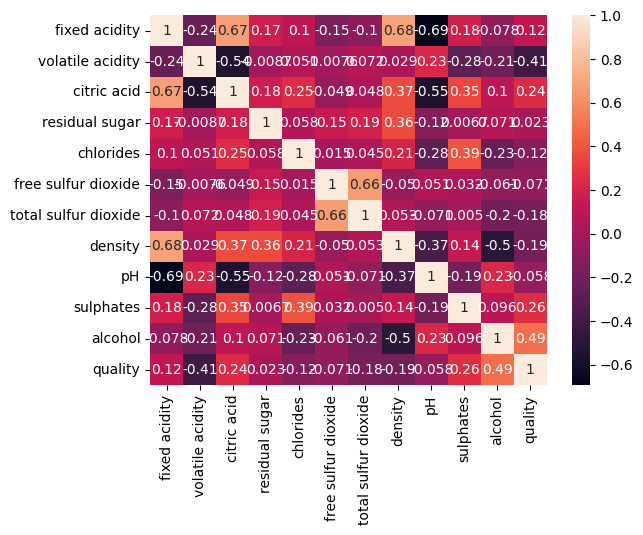

In [111]:

corr = wine_data.corr()
plt.Figure(figsize=(10,12))
sns.heatmap(data=corr ,annot=True )
plt.show()



manual method using scatterplot 

<Figure size 1000x1000 with 0 Axes>

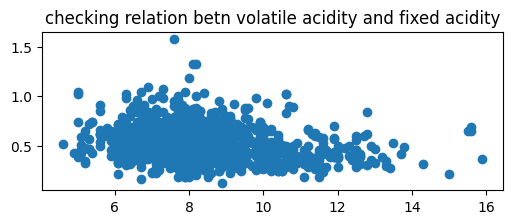

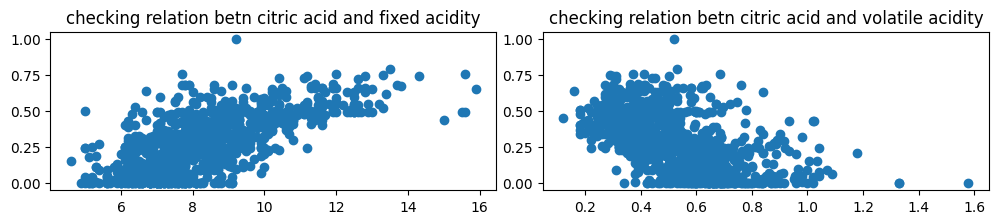

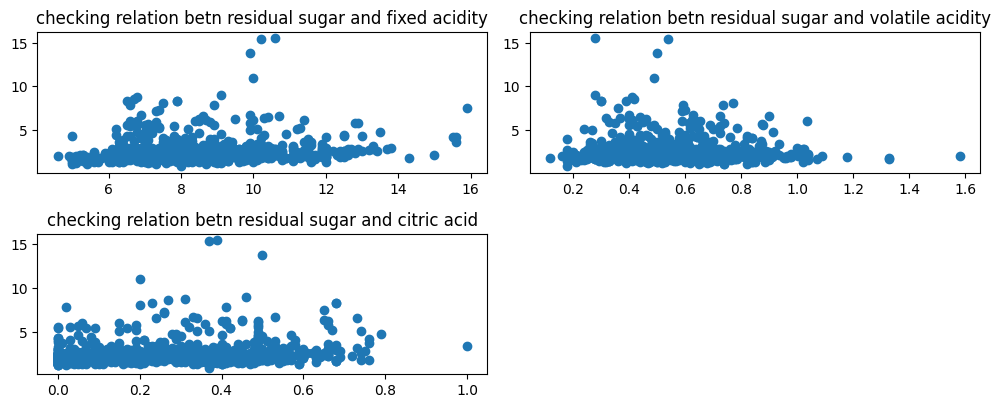

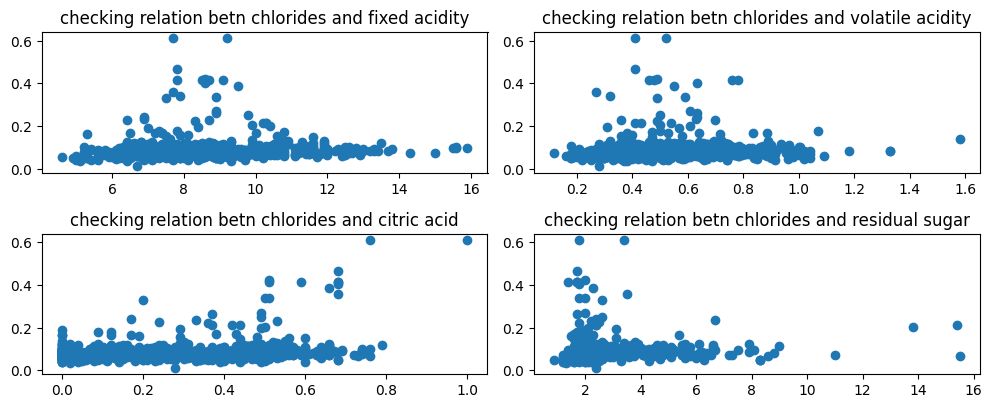

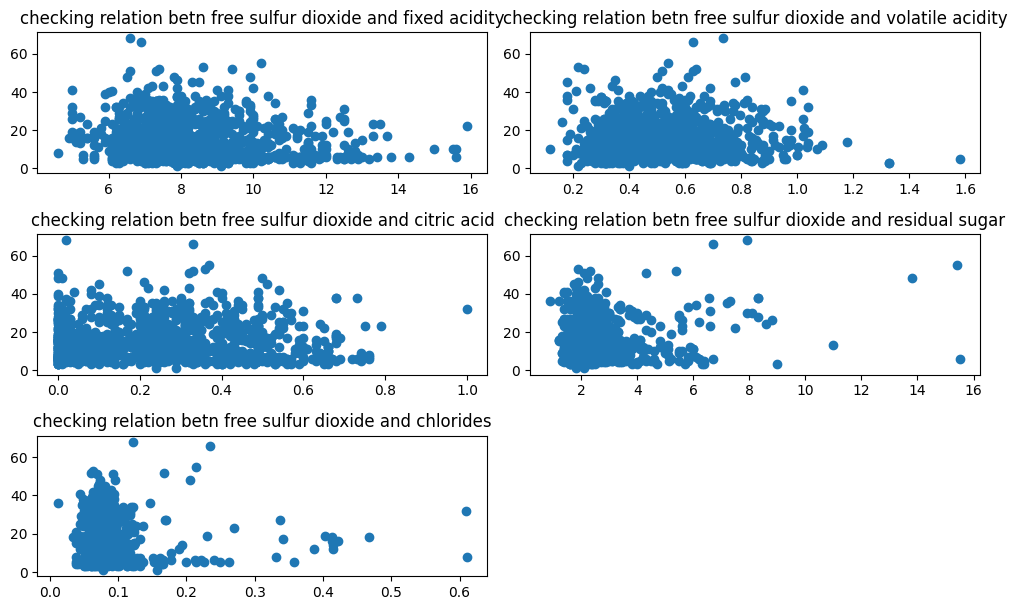

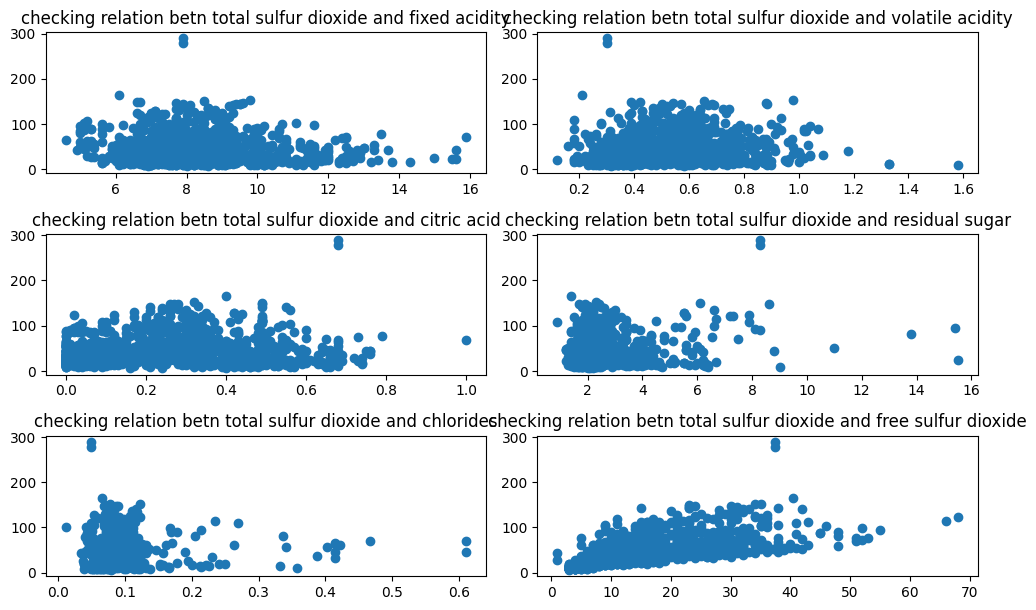

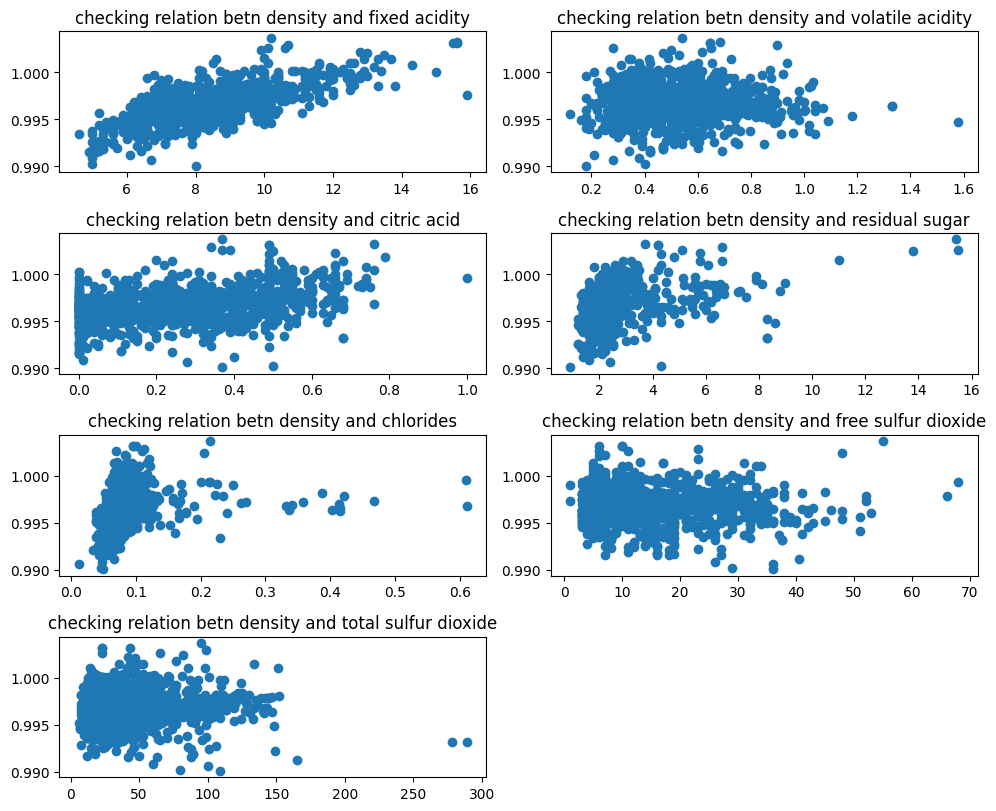

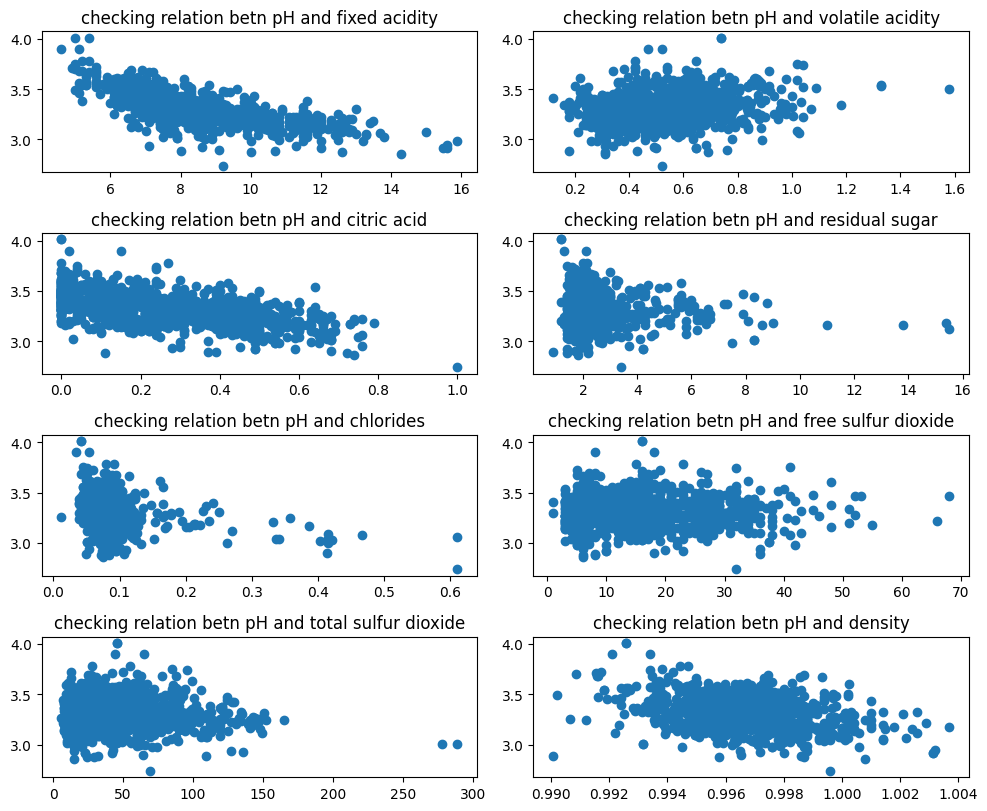

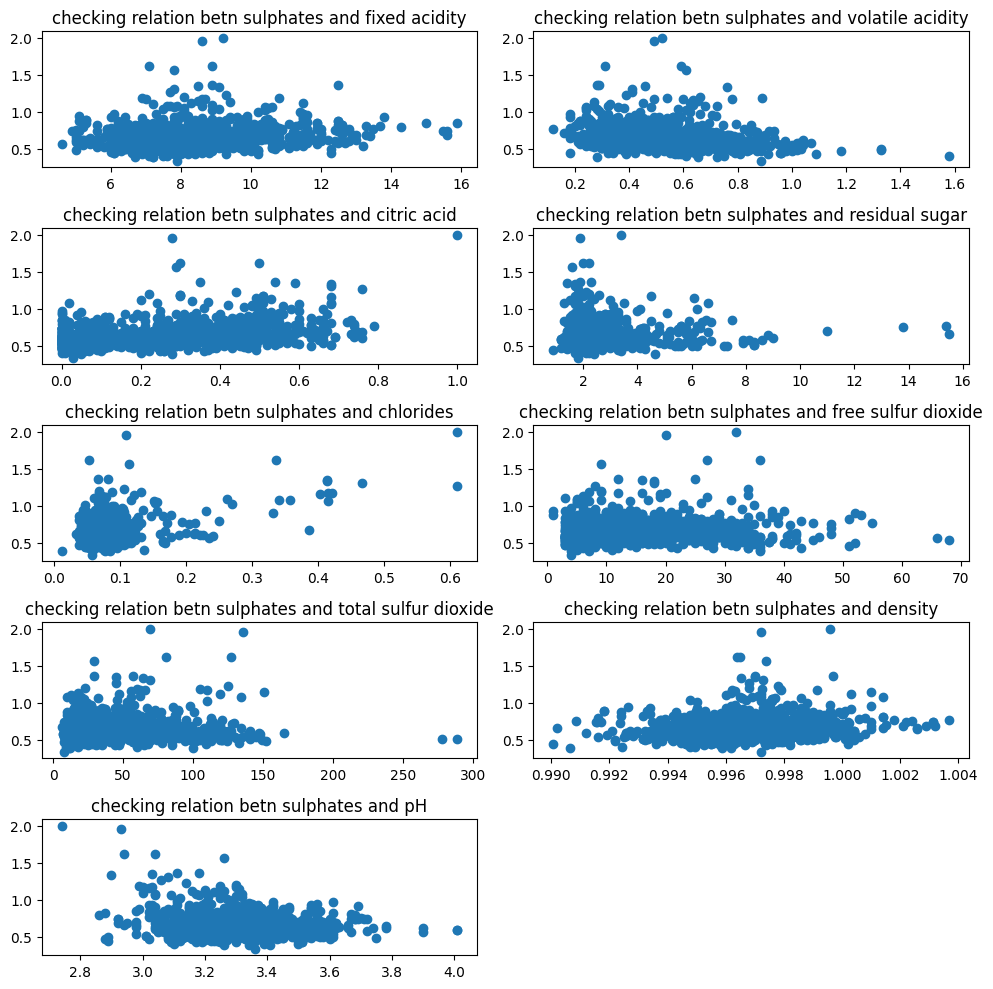

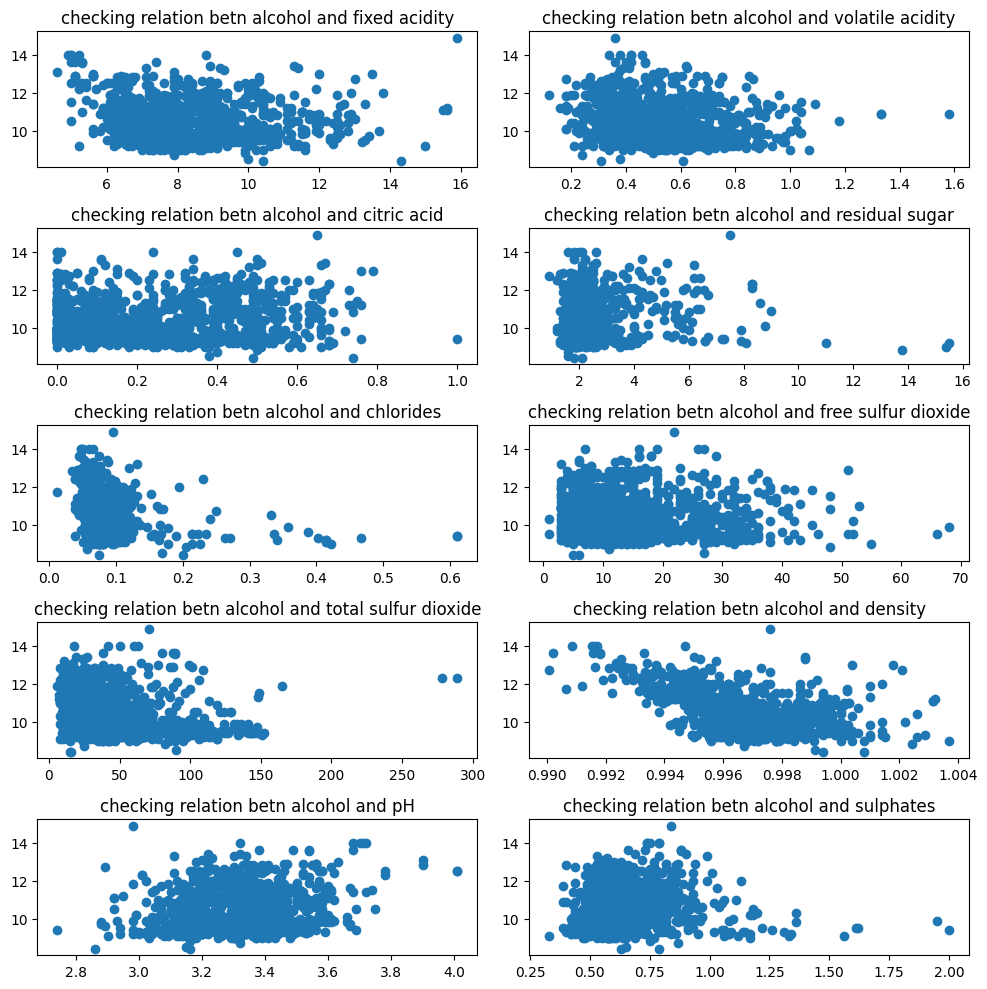

In [43]:

# almost all the coloumn are the numerical lets see the corrletion betn the tables using the scater plot

for i in range(len(columns)):
    plt.figure(figsize=(10,10))
    for j in range(len(columns)):
        if i<=j:
            continue
        plt.subplot(5,2,j+1) 
        plt.scatter(x=wine_data[columns[j]],y=wine_data[columns[i]])
        plt.title(f"checking relation betn {columns[i]} and {columns[j]}")
    plt.tight_layout()
    plt.show()

other method 

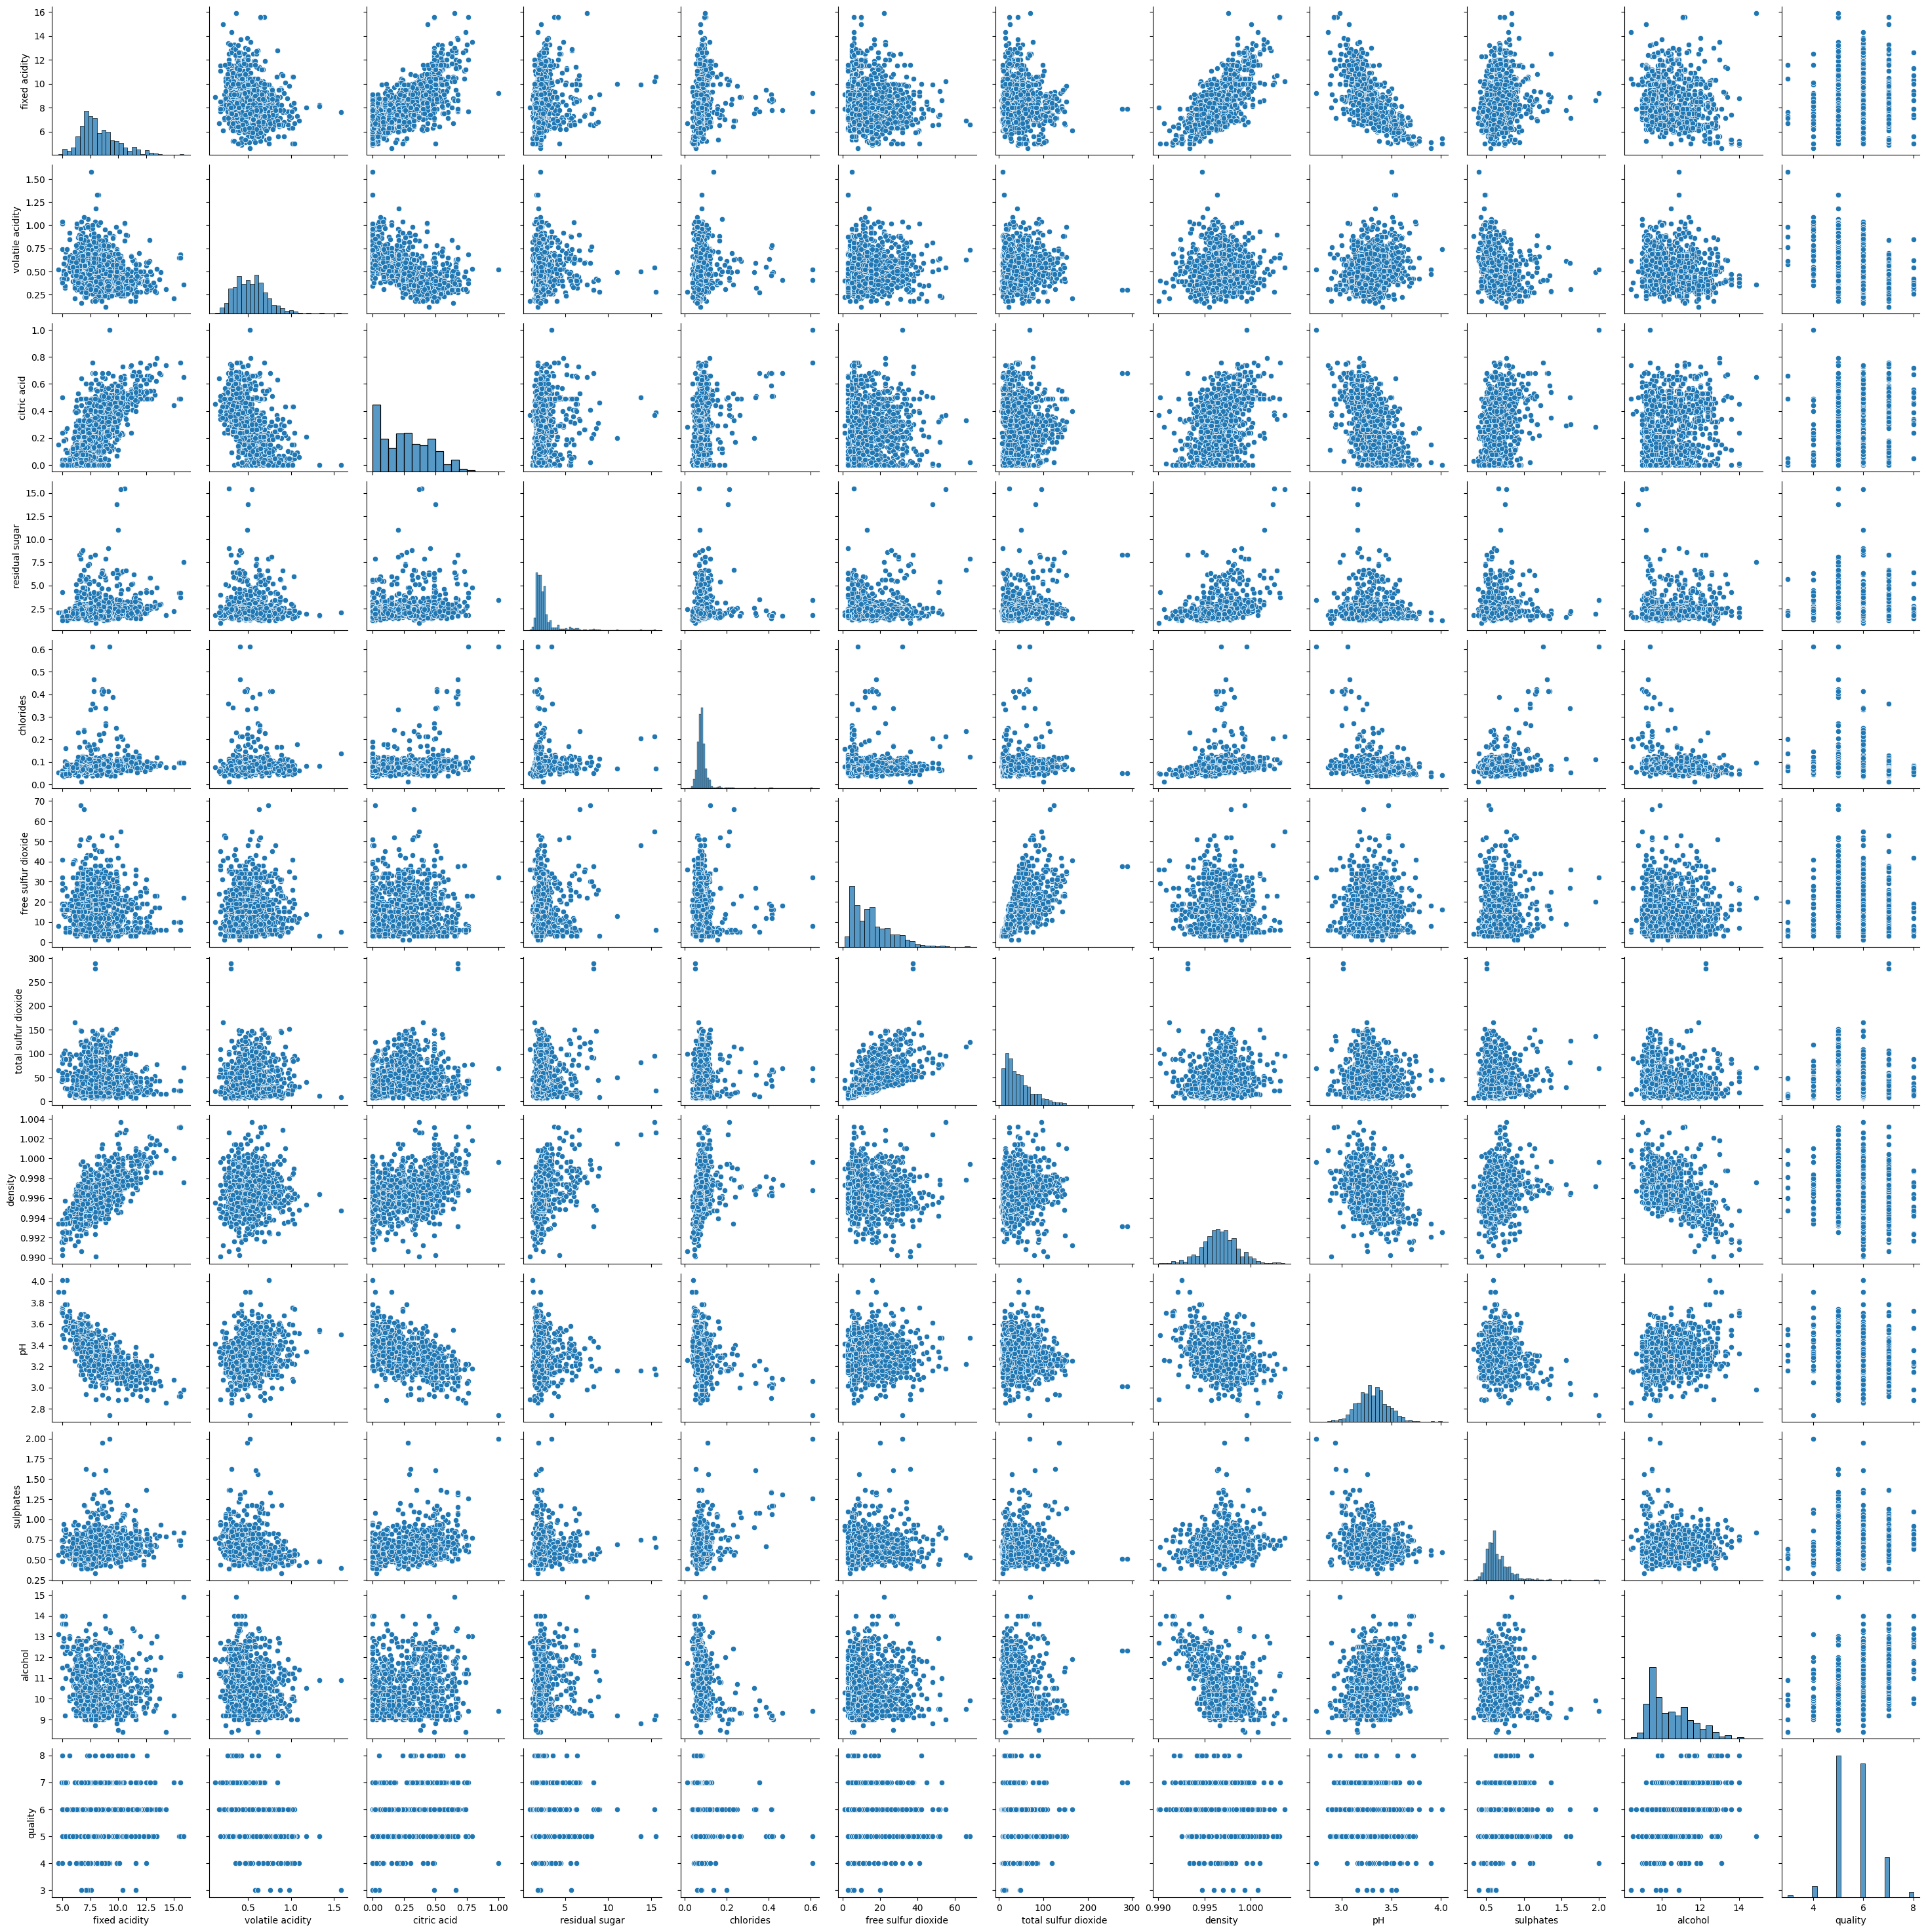

In [44]:
plt.Figure(figsize=(10,10))
sns.pairplot(data=wine_data)
plt.show()

# removing the columns
## removing the terms by 0.5 and -0.5
## the columns to be removed 
fixed acidity

volatile acidity

PH 

alcohol


In [8]:
pd.Series(columns)

0            fixed acidity
1         volatile acidity
2              citric acid
3           residual sugar
4                chlorides
5      free sulfur dioxide
6     total sulfur dioxide
7                  density
8                       pH
9                sulphates
10                 alcohol
dtype: str

In [9]:
data=wine_data.drop(columns=['fixed acidity','volatile acidity','pH','alcohol'])

lets make the target variable



In [10]:
wine_data['quality'].unique()

array([5, 6, 7, 4, 8, 3])

let the wine quality above 7 is good consider 1
below as 0

In [11]:
data['target'] = [1 if x >= 7 else 0 for x in wine_data['quality']]

## spilting the data set 

In [16]:
X=data.drop(columns=["target","quality"]).values
y=data["target"].values

In [18]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [67]:
x_train

array([[-0.96262064, -0.09466612,  0.09928181, ...,  0.36568932,
         0.31758532,  0.4419155 ],
       [-1.37050735, -0.62730788, -0.35449683, ..., -0.05718655,
        -0.10042594,  0.4419155 ],
       [ 0.51596867, -0.01857444, -0.49888094, ..., -1.20573833,
         0.85502836,  1.67443599],
       ...,
       [-1.26853567, -0.47512452,  0.18178701, ..., -0.88727624,
        -0.75730078,  0.4419155 ],
       [-1.16656399, -0.70339956, -0.99391218, ..., -0.26079346,
        -1.11559614, -0.79060499],
       [-1.16656399, -0.62730788, -0.23073902, ..., -0.15637966,
        -0.5781531 ,  0.4419155 ]], shape=(814, 8))

In [68]:
y_test

array([0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0])

## scaling

### calling standard scalar


In [19]:
scalar = StandardScaler()

In [ ]:
x_train=scalar.fit_transform(x_train)

In [21]:
x_test=scalar.transform(x_test)

In [23]:
x_train

array([[-0.94592666, -0.09045487,  0.09455068, ..., -0.19328976,
         0.34376072,  0.32373714],
       [-1.35070221, -0.63442518, -0.34673512, ..., -0.90201889,
        -0.06529772, -0.09313387],
       [ 0.52138473, -0.01274483, -0.48714423, ..., -0.19328976,
        -1.17632067,  0.85971416],
       ...,
       [-1.24950833, -0.47900509,  0.17478446, ..., -0.48859357,
        -0.86826431, -0.74821689],
       [-1.14831444, -0.71213523, -0.96854692, ..., -1.13826193,
        -0.26225179, -1.10553491],
       [-1.14831444, -0.63442518, -0.22638444, ..., -0.48859357,
        -0.16124971, -0.56955789]], shape=(814, 7))

## using the MLP model for the data set  using 3 hidden layers and 10 epochs for training data

In [63]:
# select epoch , hidden layer and lr manullay or else it will initilaize with base 

model=MLP(HL=3,epoch=100)

In [64]:
model.fit(x_train,y_train)

Epoch 0, Loss: 0.011675300702969828


### model is trained using 80 percent of the data
### now prediction is 

In [65]:
y_predict=model.predict(x_test)

In [66]:
y_predict

array([0.00979587, 0.61932476, 0.69574166, 0.09293733, 0.01927776,
       0.09937451, 0.72145035, 0.06890053, 0.02196126, 0.39179655,
       0.03162125, 0.08511557, 0.04685472, 0.01294599, 0.46362652,
       0.09314421, 0.65126046, 0.21384644, 0.01047636, 0.01241146,
       0.02213791, 0.01883241, 0.04888613, 0.02380546, 0.29600744,
       0.01806245, 0.02029998, 0.01033645, 0.19051602, 0.03078006,
       0.2003852 , 0.06886962, 0.06653133, 0.01594569, 0.43322513,
       0.01000263, 0.0222373 , 0.00950669, 0.03001091, 0.01102768,
       0.72116241, 0.01517214, 0.00929079, 0.71224545, 0.06720316,
       0.23845135, 0.00843754, 0.51635249, 0.69766491, 0.37649429,
       0.39075137, 0.10147119, 0.04168024, 0.03616592, 0.45972716,
       0.01668407, 0.0950324 , 0.54883583, 0.03608449, 0.66535015,
       0.01791482, 0.6695473 , 0.57055243, 0.35609752, 0.63296454,
       0.00867228, 0.01241801, 0.02788364, 0.01272162, 0.07997738,
       0.15891313, 0.04326839, 0.02263204, 0.35281977, 0.62249

## marking the threshold

In [67]:
predicted=[1 if x >0.5 else 0 for x in y_predict]

In [68]:
cm=confusion_matrix(y_pred=predicted,y_true=y_test)

## confusion matrix 

In [69]:
print(cm)

[[160  12]
 [ 13  19]]


In [70]:
report=classification_report(y_test,predicted)

In [71]:
print("classification report : \n " , report)

classification report : 
                precision    recall  f1-score   support

           0       0.92      0.93      0.93       172
           1       0.61      0.59      0.60        32

    accuracy                           0.88       204
   macro avg       0.77      0.76      0.77       204
weighted avg       0.88      0.88      0.88       204



# summary

#### successfully loaded the dataset in the dataFrame and cleaned the data with missing values and duplicated values 

#### then used standard scalar to nomarlize the data

#### then spilt the data in 4 :1 for the trainng and testing 

#### given the features for the MLP model and fit the data int model

#### using test data for the prediction 

#### built the confusion matrix and the classsification report 

#### model gets the accuracy of 88 % and very good recall scores for 100 epoch of training 

#### there is minimal error in the classification but the model predicts good 

